<a href="https://colab.research.google.com/github/Zidane86-06/Data_Engineering_workshop/blob/main/Day2/Day2_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [2]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print(f"Columns:{df.columns}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30students,13columns
Columns:Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [3]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Total students in the database:{count}")


Total students in the database:30


In [4]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [7]:
query1=""" Select round(avg(programming_score),2) as avg_programming from students where gender="Female" group by gender"""
result1=run_query(query1, "Average programming scores for female students")
result1

Average programming scores for female students


,avg_programming
0,70.2


In [14]:
query2=""" Select department, round(avg(attendance_percentage),2) as "avg attendance" from students group by department having "avg attendance" > 85 order by avg(attendance_percentage) desc"""
result2=run_query(query2, "Average attendance percentage by department")
result2

Average attendance percentage by department


,department,avg attendance
0,Computer Science,90.69


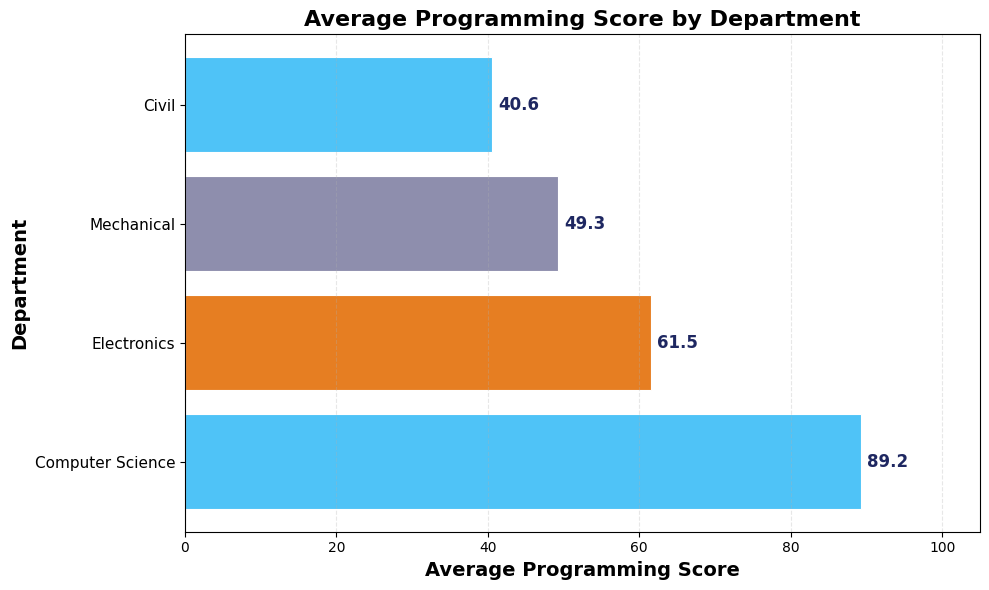

In [15]:
chart1_sql="""
select department,Round(AVG(programming_score),2) as avg_programming_score
from students
group by department
order by avg_programming_score desc
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#4FC3F7","#E67E22","#8E8EAD"]
bars=ax.barh(
    chart1_data["department"],
    chart1_data["avg_programming_score"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8)
for bar in bars:
  width=bar.get_width()
  ax.text(
      width+0.8,
      bar.get_y()+bar.get_height()/2,
      f'{width:.1f}', # Changed from % to just score
      ha='left',va='center',
      fontsize=12,fontweight='bold',
      color='#1E2761'
      )
  ax.set_title('Average Programming Score by Department',fontsize=16,fontweight='bold')
  ax.set_ylabel('Department',fontsize=14,fontweight='bold')
  ax.set_xlabel('Average Programming Score',fontsize=14,fontweight='bold')
  ax.set_xlim(0,105) # Keep 0-100 range for scores
  ax.tick_params(axis='y',labelsize=11)
  ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()